# 04 — Monte Carlo Option Pricing

European option pricing using risk-neutral Geometric Brownian Motion simulation, with Black-Scholes comparison and convergence analysis.


Geometric Brownian Motion (GBM) is widely used in finance to model stock prices, and it is mathematically defined by the stochastic differential equation:$$dS_t = \mu S_t dt + \sigma S_t dW_t$$
Where:
* $S_t$ is the asset price at time $t$
* $\mu$ is the drift coefficient (expected return)
* $\sigma$ is the volatility
* $W_t$ is a Wiener process (Standard Brownian Motion)

Key Highlights of this Code:\
Vectorized with NumPy: Instead of slow for loops, it utilizes np.cumsum across columns to calculate all steps and multiple paths simultaneously, making it incredibly fast.The Log-Normal Solution: It uses the exact analytical solution to the SDE:$$S_t = S_0 \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t\right)$$This avoids the drift errors that accumulate when using basic Euler-Maruyama approximations.

The Exact Incremental FormulaTo find the asset price at the next time step ($S_{t + \Delta t}$) based on the current price ($S_t$), use the following formula:$$S_{t + \Delta t} = S_t \cdot \exp \left( \left( \mu - \frac{1}{2}\sigma^2 \right) \Delta t + \sigma \epsilon \sqrt{\Delta t} \right)$$Where:
* $S_t$ = Current asset price at time $t$
* $S_{t + \Delta t}$ = Next asset price at time $t$ + $\Delta t$
* $\mu$ = Annualized drift coefficient (expected return)
* $\sigma$ = Annualized volatility coefficient
* $\Delta t$ = Time step size in years (e.g., $1/252$ for daily steps in a trading year)
* $\epsilon$ = A random draw from a standard normal distribution, where $\epsilon \sim N(0, 1)$

To incorporate a continuous dividend yield ($q$) into the Geometric Brownian Motion (GBM) simulation, the drift coefficient ($\mu$) is adjusted to account for the value "leaking" out of the stock price as dividends.The stochastic differential equation becomes:$$dS_t = (\mu - q) S_t dt + \sigma S_t dW_t$$Accordingly, the exact incremental formula used for path generation drops the drift term from $\mu$ to $\mu - q$:$$S_{t + \Delta t} = S_t \cdot \exp \left( \left( \mu - q - \frac{1}{2}\sigma^2 \right) \Delta t + \sigma \epsilon \sqrt{\Delta t} \right)$$



## Setup


In [13]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from src.pricing.fallback_bs import black_scholes_greeks
from src.pricing.monte_carlo import (
    convergence_analysis,
    price_european_option_mc,
    simulate_gbm_paths,
)


## Pricing inputs


In [14]:
spot = 100.0
strike = 100.0
maturity_years = 1.0
rate = 0.05
volatility = 0.20
option_type = 'Call'
num_paths = 100_000
seed = 42


## Simulate sample GBM paths


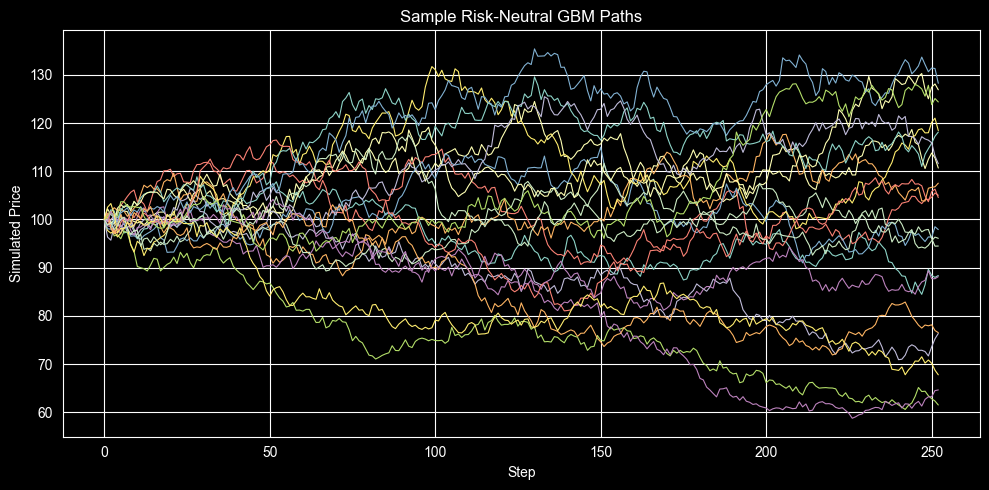

In [15]:
paths = simulate_gbm_paths(spot, maturity_years, rate, volatility, num_paths=20, num_steps=252, seed=seed)
plt.figure(figsize=(10, 5))
for i in range(min(20, paths.shape[0])):
    plt.plot(paths[i], linewidth=0.8)
plt.title('Sample Risk-Neutral GBM Paths')
plt.xlabel('Step')
plt.ylabel('Simulated Price')
plt.tight_layout()


## Monte Carlo price vs Black-Scholes


In [16]:
mc = price_european_option_mc(spot, strike, maturity_years, rate, volatility, option_type, num_paths=num_paths, seed=seed)
bs = black_scholes_greeks(spot, strike, maturity_years, rate, volatility, option_type)
print(f'Monte Carlo price: {mc.price:.6f}')
print(f'95% CI: [{mc.confidence_interval_low:.6f}, {mc.confidence_interval_high:.6f}]')
print(f'Black-Scholes price: {bs.price:.6f}')
print(f'Absolute error: {abs(mc.price - bs.price):.6f}')


Monte Carlo price: 10.467314
95% CI: [10.375741, 10.558888]
Black-Scholes price: 10.450584
Absolute error: 0.016731


## Convergence analysis


In [17]:
conv = convergence_analysis(spot, strike, maturity_years, rate, volatility, option_type, seed=seed)
conv


,num_paths,mc_price,standard_error,ci_low,ci_high,black_scholes_price,absolute_error,relative_error_pct,option_type,antithetic,seed
0,1000,10.000398,0.444738,9.128711,10.872085,10.450584,0.450186,4.307757,Call,True,42
1,5000,10.450949,0.210584,10.038206,10.863693,10.450584,0.000366,0.003501,Call,True,42
2,10000,10.410052,0.147531,10.120892,10.699212,10.450584,0.040532,0.387843,Call,True,42
3,25000,10.447731,0.093678,10.264122,10.631341,10.450584,0.002852,0.027292,Call,True,42
4,50000,10.454935,0.066014,10.325547,10.584323,10.450584,0.004352,0.041641,Call,True,42
5,100000,10.467314,0.046721,10.375741,10.558888,10.450584,0.016731,0.160092,Call,True,42


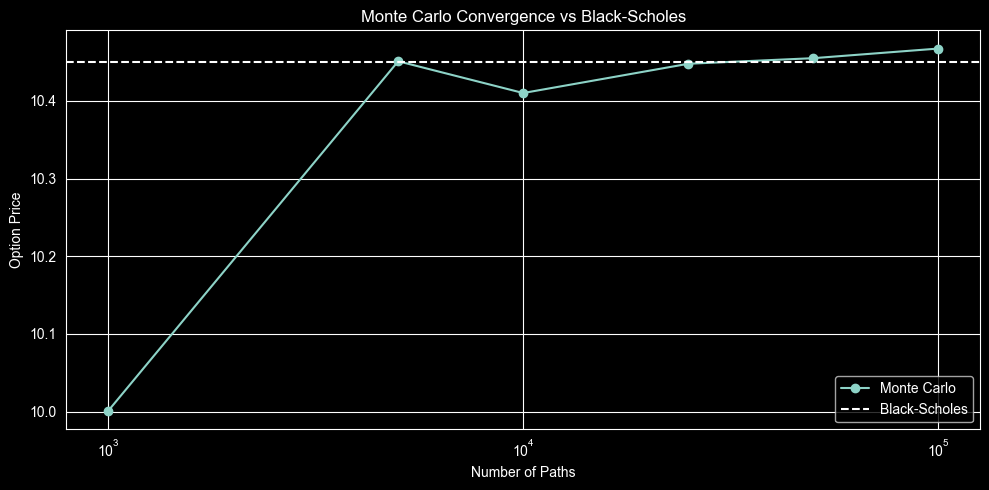

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(conv['num_paths'], conv['mc_price'], marker='o', label='Monte Carlo')
plt.axhline(conv['black_scholes_price'].iloc[0], linestyle='--', label='Black-Scholes')
plt.xscale('log')
plt.title('Monte Carlo Convergence vs Black-Scholes')
plt.xlabel('Number of Paths')
plt.ylabel('Option Price')
plt.legend()
plt.tight_layout()
